# Laguerre Polynomials

Laguerre polynomials are a sequence of polynomials defined on the interval $[0,\infty)$. The generalized Laguerre polynomials are denoted by $L_n^{(\alpha)}(x)$, where $n$ is the polynomial degree and $\alpha$ is a parameter. The ordinary Laguerre polynomials correspond to the special case $\alpha=0$:

$$
L_0(x) = 1,\quad
L_1(x) = 1 - x,\quad
L_2(x) = 1 - 2x + \frac{x^2}{2}.
$$

The generalized Laguerre polynomials are orthogonal on $[0,\infty)$ with respect to the weight function $x^\alpha e^{-x}$:

$$
\int_0^\infty x^\alpha e^{-x}L_n^{(\alpha)}(x)L_m^{(\alpha)}(x)\,dx = \frac{\Gamma(n+\alpha+1)}{n!}\delta_{nm}.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Laguerre

In [2]:
plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

## Hydrogen Atom

Laguerre polynomials naturally appear when solving the Schrödinger equation for the hydrogen atom. The time-independent Schrödinger equation is

$$
-\left[\frac{\hbar^2}{2\mu}\nabla^2 + \frac{e^2}{4\pi\epsilon_0 r}\right]\Psi = E\Psi.
$$

Because the potential depends only on the radial coordinate $r$, the wavefunction can be separated into radial and angular parts:

$$
\Psi_{nlm}(r,\theta,\phi) = R_{nl}(r)Y_l^m(\theta,\phi).
$$

The quantum numbers $n$, $l$, and $m$ label the hydrogen-atom eigenstates, with $n$ determining the energy level and $l$ determining the angular momentum.

In atomic units, where $\hbar = e = \mu = 4\pi\epsilon_0 = 1$, the Bohr radius is $a_0 = 1$. After separating the angular part, the radial solution can be written as

$$
R_{nl}(r) \propto r^le^{-r/n}L_{n-l-1}^{2l+1}\left(\frac{2r}{n}\right),
$$

where $L_{n-l-1}^{2l+1}$ is an associated Laguerre polynomial. The polynomial degree is determined by the quantum numbers:

$$
\deg = n - l - 1.
$$

For the example

$$
n = 3,\quad
l = 0,
$$

the degree is

$$
\deg = 3 - 0 - 1 = 2.
$$

Thus, the radial dependence contains a second-degree Laguerre polynomial evaluated at the scaled coordinate

$$
\frac{2r}{n}.
$$

The radial wavefunction describes how the probability amplitude varies with the distance $r$ from the nucleus. Together with the angular function $Y_l^m(\theta,\phi)$, it gives the complete hydrogen-atom wavefunction,

$$
\Psi_{nlm}(r,\theta,\phi) = R_{nl}(r)Y_l^m(\theta,\phi).
$$

The quantum numbers therefore determine the structure of the state, including its radial behavior and number of radial nodes.

In [3]:
r = np.linspace(0, 20, 1000)
n, l = 3, 0
alpha = 2 * l + 1
deg = n - l - 1

In [4]:
R = lambda n, l, r: (r**l) * np.exp(-r/n) * Laguerre([0]*deg + [1])(2*r/n)

The radial function is evaluated over

$$
r\in[0,20]
$$

and plotted as a function of the radial coordinate $r$.

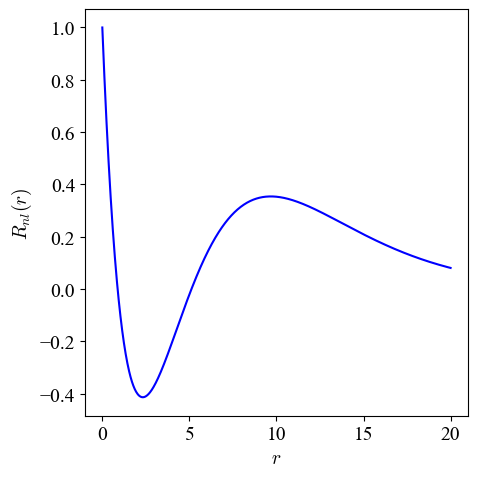

In [5]:
plt.figure(figsize=(5, 5))
plt.plot(r, R(n, l, r), "b")
plt.xlabel(r"$r$")
plt.ylabel(r"$R_{nl}(r)$")
plt.tight_layout()
plt.show()